<a href="https://colab.research.google.com/github/pandeychetanya/HalloweenFlutter/blob/main/segment_first_main_seq_bulk.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:

import sys

!{sys.executable} -m pip uninstall -y numpy scipy
!{sys.executable} -m pip install --no-cache-dir "numpy==2.0.2" "scipy==1.16.3"

print("STOP HERE. Now go to Runtime → Restart runtime, then run the next setup cell.")

Found existing installation: numpy 2.0.2
Uninstalling numpy-2.0.2:
  Successfully uninstalled numpy-2.0.2
Found existing installation: scipy 1.16.3
Uninstalling scipy-1.16.3:
  Successfully uninstalled scipy-1.16.3
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.9/60.9 kB 980.0 kB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.2/19.2 MB 80.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.7/35.7 MB 80.0 MB/s eta 0:00:00
STOP HERE. Now go to Runtime → Restart runtime, then run the next setup cell.


In [2]:
import sys
import os
import importlib
from pathlib import Path

import numpy as np
import pandas as pd

from google.colab import drive

# -------------------------
# 0. Mount Drive
# -------------------------


# drive.flush_and_unmount()

drive.mount("/content/drive", force_remount=True)

# -------------------------
# 1. Install dependencies
# -------------------------

!{sys.executable} -m pip install -q --force-reinstall "numpy<2.1,>=1.22" "pandas==2.2.2"
!{sys.executable} -m pip uninstall -y eyelinkio
!{sys.executable} -m pip install -q --no-deps --force-reinstall git+https://github.com/pandeychetanya/eyelinkio.git@chetanyaedits

# -------------------------
# 2. Add eyeprocess repo
# -------------------------

REPO_DIR = Path("/content/drive/MyDrive/eyeprocess")

assert REPO_DIR.exists(), f"Missing repo folder: {REPO_DIR}"

if str(REPO_DIR) not in sys.path:
    sys.path.insert(0, str(REPO_DIR))

importlib.invalidate_caches()

# -------------------------
# 3. Imports from eyeprocess
# -------------------------

from eyeprocess.utils.psychopy import el2deg
from eyeprocess.utils.saccades import SegmentationParams, eye_movement_segmentation
from eyeprocess.utils.main_sequence_helpers import (
    read_edf_like_pyedfread,
    load_behav_json,
    build_calib_params,
    parse_trials_from_messages,
    get_affine_for_trial,
)

print("Imports worked.")



# -------------------------
# 4. Paths
# -------------------------

DATA_ROOT = Path("/content/drive/MyDrive/steer_search_PD/steer-search-PD")
assert DATA_ROOT.exists(), f"Missing DATA_ROOT: {DATA_ROOT}"

OUT_DIR = Path("/content/drive/MyDrive/steer_search_PD/main_sequence_outputs")
OUT_DIR.mkdir(parents=True, exist_ok=True)

print("DATA_ROOT:", DATA_ROOT)
print("OUT_DIR:", OUT_DIR)


# ============================================================
# Block-level segmentation, then filter to image-onset/response
# ============================================================

def process_one_block_for_main_sequence(
    trials_df,
    samples,
    events,
    calib_params,
    subject_id,
    group,
    block_id,
    min_saccade_speed_deg_s=50.0,
):
    samples_block = samples.copy().reset_index(drop=True)

    time_ms = samples_block["time"].to_numpy(dtype=float)
    x_pix = samples_block["gx_left"].to_numpy(dtype=float)
    y_pix = samples_block["gy_left"].to_numpy(dtype=float)

    x_deg, y_deg = el2deg(x_pix, y_pix)

    # full-block arrays
    x = np.full(len(samples_block), np.nan, dtype=float)
    y = np.full(len(samples_block), np.nan, dtype=float)

    sample_trial = np.full(len(samples_block), -1, dtype=int)
    sample_calib = np.full(len(samples_block), -1, dtype=int)

    trial_info = {}

    # -------------------------
    # 1. Calibrate block piecewise by trial
    # -------------------------
    for _, trial_row in trials_df.iterrows():

        trial_num = int(trial_row["trial"])

        image_onset = float(trial_row["image_onset_ms"])
        response = float(trial_row["response_ms"])

        seg_start = image_onset
        seg_end = response

        calib_session_id, affine = get_affine_for_trial(calib_params, trial_num)

        m = (time_ms >= seg_start) & (time_ms <= seg_end)

        if m.sum() == 0:
            continue

        xy_calib = affine.transform(
            np.column_stack([x_deg[m], y_deg[m]])
        )

        x[m] = xy_calib[:, 0]
        y[m] = xy_calib[:, 1]

        sample_trial[m] = trial_num
        sample_calib[m] = calib_session_id

        trial_info[trial_num] = {
            "trial": trial_num,
            "image": trial_row["image"],
            "stim_id": f"{block_id}_{trial_row['image']}",
            "rt_ms": trial_row["rt_ms"],
            "rt_from_response_ms": trial_row.get("rt_from_response_ms", np.nan),
            "image_onset_ms": image_onset,
            "response_ms": response,
            "calib_session_id": calib_session_id,
        }

    # -------------------------
    # 2. Remove blink samples in full block
    # -------------------------
    blink_mask = np.zeros(len(samples_block), dtype=bool)

    blinks_block = events[events["type"] == "blink"].copy()

    for _, blink_row in blinks_block.iterrows():
        bm = (
            (time_ms >= float(blink_row["start"])) &
            (time_ms <= float(blink_row["end"]))
        )
        blink_mask |= bm

    x[blink_mask] = np.nan
    y[blink_mask] = np.nan

    # -------------------------
    # 3. Estimate sampling rate and segment full block
    # -------------------------
    fs = float(round(1000.0 / np.nanmedian(np.diff(time_ms))))

    params = SegmentationParams(
        fs=fs,
        winsize=13,
        min_saccade_speed=min_saccade_speed_deg_s / 60.0,
        start_vel=18.0 / 60.0,
        min_peak_prominence=30.0 / 60.0,
        drift_min_duration_ms=100.0,
    )

    result = eye_movement_segmentation(
        x,
        y,
        params,
        return_speed=True,
    )

    # -------------------------
    # 4. Keep only events inside image_onset-response
    # -------------------------
    saccade_rows = []
    fixation_rows = []
    trial_saccade_counts = {}
    trial_fixation_counts = {}

    def assign_event_to_trial(start_idx, stop_idx):
        start_t = time_ms[start_idx]
        stop_t = time_ms[stop_idx]

        candidate_trials = []

        for trial_num, info in trial_info.items():
            if (
                start_t >= info["image_onset_ms"] and
                stop_t <= info["response_ms"]
            ):
                candidate_trials.append(trial_num)

        if len(candidate_trials) == 0:
            return None

        return candidate_trials[0]

    # -------------------------
    # Saccades
    # -------------------------
    for s in result.saccades:

        trial_num = assign_event_to_trial(s.start, s.stop)

        if trial_num is None:
            continue

        info = trial_info[trial_num]

        i = trial_saccade_counts.get(trial_num, 0)
        trial_saccade_counts[trial_num] = i + 1

        saccade_rows.append({
            "subject_id": subject_id,
            "group": group,
            "block_id": block_id,
            "trial": trial_num,
            "image": info["image"],
            "stim_id": info["stim_id"],
            "rt_ms": info["rt_ms"],
            "rt_from_response_ms": info["rt_from_response_ms"],

            "saccade_index": i,
            "start_idx_block": s.start,
            "stop_idx_block": s.stop,
            "start_time_ms": time_ms[s.start],
            "stop_time_ms": time_ms[s.stop],
            "onset_ms_from_image": time_ms[s.start] - info["image_onset_ms"],
            "offset_ms_from_image": time_ms[s.stop] - info["image_onset_ms"],

            "duration_ms": s.duration_ms,
            "amplitude_deg": s.amplitude,
            "peak_speed_internal": s.peak_speed,
            "peak_velocity_deg_s": s.peak_speed * 60.0,
            "is_microsaccade": s.is_microsaccade,

            "fs": fs,
            "winsize": params.winsize,
            "min_saccade_speed_deg_s": min_saccade_speed_deg_s,
            "drift_min_duration_ms": params.drift_min_duration_ms,

            "calib_session_id": info["calib_session_id"],
        })

    # -------------------------
    # Fixations / drifts
    # -------------------------
    for d in result.drifts:

        trial_num = assign_event_to_trial(d.start, d.stop)

        if trial_num is None:
            continue

        info = trial_info[trial_num]

        i = trial_fixation_counts.get(trial_num, 0)
        trial_fixation_counts[trial_num] = i + 1

        fixation_rows.append({
            "subject_id": subject_id,
            "group": group,
            "block_id": block_id,
            "trial": trial_num,
            "image": info["image"],
            "stim_id": info["stim_id"],

            "fixation_index": i,
            "start_idx_block": d.start,
            "stop_idx_block": d.stop,
            "start_time_ms": time_ms[d.start],
            "stop_time_ms": time_ms[d.stop],
            "onset_ms_from_image": time_ms[d.start] - info["image_onset_ms"],
            "offset_ms_from_image": time_ms[d.stop] - info["image_onset_ms"],

            "duration_ms": d.duration_ms,
            "x_deg": float(np.nanmean(d.x_raw)),
            "y_deg": float(np.nanmean(d.y_raw)),
            "mean_speed": d.speed,

            "calib_session_id": info["calib_session_id"],
        })

    # -------------------------
    # Trial summaries
    # -------------------------
    trial_rows = []

    sac_df = pd.DataFrame(saccade_rows)
    fix_df = pd.DataFrame(fixation_rows)

    for trial_num, info in trial_info.items():

        ssub = sac_df[sac_df["trial"] == trial_num] if len(sac_df) else pd.DataFrame()
        fsub = fix_df[fix_df["trial"] == trial_num] if len(fix_df) else pd.DataFrame()

        trial_rows.append({
            "subject_id": subject_id,
            "group": group,
            "block_id": block_id,
            "trial": trial_num,
            "image": info["image"],
            "stim_id": info["stim_id"],
            "rt_ms": info["rt_ms"],
            "rt_from_response_ms": info["rt_from_response_ms"],
            "calib_session_id": info["calib_session_id"],

            "n_saccades": len(ssub),
            "n_fixations": len(fsub),

            "median_saccade_amp": (
                ssub["amplitude_deg"].median() if len(ssub) else np.nan
            ),
            "median_peak_velocity": (
                ssub["peak_velocity_deg_s"].median() if len(ssub) else np.nan
            ),
            "median_saccade_duration": (
                ssub["duration_ms"].median() if len(ssub) else np.nan
            ),
            "first_saccade_latency_ms": (
                ssub["onset_ms_from_image"].min() if len(ssub) else np.nan
            ),
            "status": "ok",
        })

    return saccade_rows, fixation_rows, trial_rows

Mounted at /content/drive
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.9/60.9 kB 856.1 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.7/12.7 MB 36.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.2/19.2 MB 31.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 229.9/229.9 kB 17.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 510.1/510.1 kB 31.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 349.3/349.3 kB 28.7 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
Imports worked.
DATA_ROOT: /content/drive/MyDrive/steer_search_PD/steer-search-PD
OUT_DIR: /content/drive/MyDrive/steer_search_PD/main_sequence_outputs


In [3]:
# ============================================================
# Run all blocks for one chosen subject
# Block-level segmentation version
# ============================================================

SUBJECT_ID = "s189"

from pathlib import Path
import numpy as np
import pandas as pd

DATA_ROOT = Path("/content/drive/MyDrive/steer_search_PD/steer-search-PD")
OUT_DIR = Path("/content/drive/MyDrive/steer_search_PD/main_sequence_outputs")
OUT_DIR.mkdir(parents=True, exist_ok=True)

subject_dir = DATA_ROOT / SUBJECT_ID
behav_dir = subject_dir / "behav"
eye_dir = subject_dir / "eye"

assert behav_dir.exists(), f"Missing behav folder: {behav_dir}"
assert eye_dir.exists(), f"Missing eye folder: {eye_dir}"

group = "PD" if SUBJECT_ID.startswith("p") else "Control"

all_saccades = []
all_fixations = []
all_trials = []
failed_blocks = []

behav_files = sorted(behav_dir.glob("*.json"))

print("Subject:", SUBJECT_ID)
print("Group:", group)
print("Blocks found:", len(behav_files))

for behav_path in behav_files:

    BLOCK_ID = behav_path.stem
    edf_path = eye_dir / f"{BLOCK_ID}.edf"

    print("\nProcessing block:", BLOCK_ID)

    if not edf_path.exists():
        failed_blocks.append({
            "subject_id": SUBJECT_ID,
            "group": group,
            "block_id": BLOCK_ID,
            "reason": f"Missing EDF: {edf_path}",
        })
        print("  Skipping: missing EDF")
        continue

    try:
        behav = load_behav_json(behav_path)
        samples, events, messages = read_edf_like_pyedfread(edf_path)

        calib_params = build_calib_params(behav)

        print("Calibration sessions kept:", sorted(calib_params.keys()))

        trials_df = parse_trials_from_messages(messages)

        saccade_rows, fixation_rows, trial_rows = process_one_block_for_main_sequence(
            trials_df=trials_df,
            samples=samples,
            events=events,
            calib_params=calib_params,
            subject_id=SUBJECT_ID,
            group=group,
            block_id=BLOCK_ID,
            min_saccade_speed_deg_s=50.0,
        )

        all_saccades.extend(saccade_rows)
        all_fixations.extend(fixation_rows)
        all_trials.extend(trial_rows)

        print("  kept saccades:", len(saccade_rows))
        print("  kept fixations:", len(fixation_rows))
        print("  trials:", len(trial_rows))

    except Exception as e:
        failed_blocks.append({
            "subject_id": SUBJECT_ID,
            "group": group,
            "block_id": BLOCK_ID,
            "reason": str(e),
        })
        print("  Block failed:", e)
        continue

all_saccades_subject_df = pd.DataFrame(all_saccades)
all_fixations_subject_df = pd.DataFrame(all_fixations)
all_trials_subject_df = pd.DataFrame(all_trials)
failed_blocks_subject_df = pd.DataFrame(failed_blocks)

all_saccades_path = OUT_DIR / f"all_saccades_{SUBJECT_ID}.csv"
all_fixations_path = OUT_DIR / f"all_fixations_{SUBJECT_ID}.csv"
all_trials_path = OUT_DIR / f"all_trials_{SUBJECT_ID}.csv"
failed_blocks_path = OUT_DIR / f"failed_blocks_{SUBJECT_ID}.csv"

all_saccades_subject_df.to_csv(all_saccades_path, index=False)
all_fixations_subject_df.to_csv(all_fixations_path, index=False)
all_trials_subject_df.to_csv(all_trials_path, index=False)
failed_blocks_subject_df.to_csv(failed_blocks_path, index=False)

print("\nDone")
print("Saccades:", len(all_saccades_subject_df))
print("Fixations:", len(all_fixations_subject_df))
print("Trials:", len(all_trials_subject_df))
print("Failed blocks:", len(failed_blocks_subject_df))

print("\nSaved:")
print(all_saccades_path)
print(all_fixations_path)
print(all_trials_path)
print(failed_blocks_path)

display(all_saccades_subject_df.head())
display(all_trials_subject_df.head())
display(failed_blocks_subject_df.head())

Subject: s189
Group: Control
Blocks found: 4

Processing block: 250807_170121
Baseline calibration for prelim diagnosis...

Worst-case RMSE for each session in RMSE
[0.9961061484355179, 1.2229048761374408, 2.9926430500866847, 7.093681040046502, 1.1008659000837466]
Using session : 0 as a baseline...


Starting baseline calibration...
Session 0, worst RMSE at position 4 is 0.9961061484355179 < 2.0
...converged
Session 1, worst RMSE at position 2 is 1.4793538678149494 < 2.0
...converged
Session 2, worst RMSE at position 13 is 3.337908980810534 > 2.0
...rejecting the data
Session 2, worst RMSE at position 8 is 1.0634218504779767 < 2.0
...converged
Session 3, worst RMSE at position 8 is 8.225189417509116 > 2.0
...rejecting the data
Session 3, worst RMSE at position 14 is 1.8627570978745116 < 2.0
...converged
Session 4, worst RMSE at position 16 is 1.3792018458279716 < 2.0
...converged

Starting consensus calibration...
Session 0, worst RMSE at position 4 is 0.9961061484355179 < 1.0
...conve

,subject_id,group,block_id,trial,image,stim_id,rt_ms,rt_from_response_ms,saccade_index,start_idx_block,...,duration_ms,amplitude_deg,peak_speed_internal,peak_velocity_deg_s,is_microsaccade,fs,winsize,min_saccade_speed_deg_s,drift_min_duration_ms,calib_session_id
0,s189,Control,250807_170121,1,044.jpg,250807_170121_044.jpg,2971.0,2970.404,0,34095,...,39.0,3.539195,5.717140,343.028372,False,1000.0,13,50.0,100.0,0
1,s189,Control,250807_170121,1,044.jpg,250807_170121_044.jpg,2971.0,2970.404,1,34359,...,67.0,9.781570,6.001286,360.077167,False,1000.0,13,50.0,100.0,0
2,s189,Control,250807_170121,1,044.jpg,250807_170121_044.jpg,2971.0,2970.404,2,34511,...,46.0,16.364137,9.290934,557.456058,False,1000.0,13,50.0,100.0,0
3,s189,Control,250807_170121,1,044.jpg,250807_170121_044.jpg,2971.0,2970.404,3,34887,...,32.0,1.868885,4.450888,267.053264,False,1000.0,13,50.0,100.0,0
4,s189,Control,250807_170121,1,044.jpg,250807_170121_044.jpg,2971.0,2970.404,4,35045,...,67.0,16.273464,7.613219,456.793158,False,1000.0,13,50.0,100.0,0


,subject_id,group,block_id,trial,image,stim_id,rt_ms,rt_from_response_ms,calib_session_id,n_saccades,n_fixations,median_saccade_amp,median_peak_velocity,median_saccade_duration,first_saccade_latency_ms,status
0,s189,Control,250807_170121,1,044.jpg,250807_170121_044.jpg,2971.0,2970.404,0,12,9,13.468783,534.088354,61.5,232.0,ok
1,s189,Control,250807_170121,2,096.jpg,250807_170121_096.jpg,2379.0,2379.157,0,6,6,9.459430,476.631278,45.0,295.0,ok
2,s189,Control,250807_170121,3,084.jpg,250807_170121_084.jpg,933.0,933.406,0,3,3,9.097647,463.432498,34.0,310.0,ok
3,s189,Control,250807_170121,4,092.jpg,250807_170121_092.jpg,1654.0,1653.306,0,7,5,12.388620,417.279819,55.0,293.0,ok
4,s189,Control,250807_170121,5,047.jpg,250807_170121_047.jpg,2077.0,2077.230,0,6,5,4.290639,342.021482,47.0,91.0,ok


""


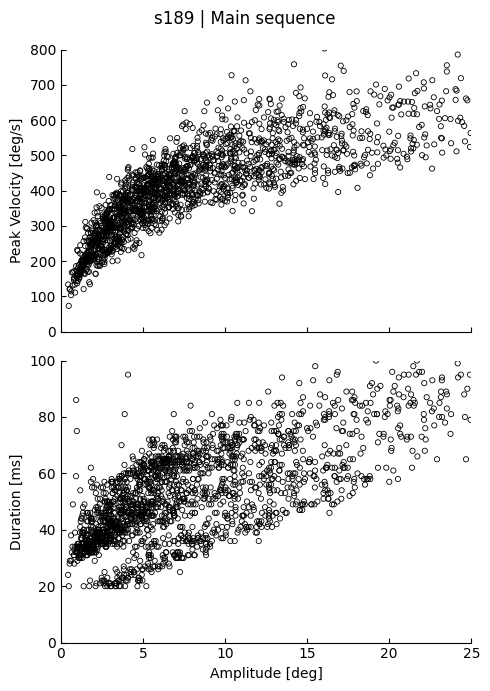

n saccades: 1816
calib_session_id
0    227
1    432
2    438
3    449
4    270
Name: count, dtype: int64
count    100.000000
mean      18.160000
std        3.979036
min        9.000000
25%       16.000000
50%       18.000000
75%       21.000000
max       29.000000
dtype: float64


In [4]:
#plotting main sequence for one subject

# ============================================================
# Plot main sequence for one subject from all_saccades_<SUBJECT_ID>.csv
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

SUBJECT_ID = "s189"

OUT_DIR = Path("/content/drive/MyDrive/steer_search_PD/main_sequence_outputs")
csv_path = OUT_DIR / f"all_saccades_{SUBJECT_ID}.csv"

df = pd.read_csv(csv_path)

# optional QC
df = df[
    (df["amplitude_deg"] > 0) &
    (df["duration_ms"] > 0) &
    (df["peak_velocity_deg_s"] > 0) &
    (df["amplitude_deg"] <= 25)
].copy()

fig, axes = plt.subplots(
    2, 1,
    figsize=(5, 7),
    sharex=True
)

# Top: amplitude vs peak velocity
axes[0].scatter(
    df["amplitude_deg"],
    df["peak_velocity_deg_s"],
    s=14,
    facecolors="none",
    edgecolors="black",
    linewidths=0.6,
)

axes[0].set_ylabel("Peak Velocity [deg/s]")
axes[0].set_ylim(0, 800)
axes[0].set_xlim(0, 25)

# Bottom: amplitude vs duration
axes[1].scatter(
    df["amplitude_deg"],
    df["duration_ms"],
    s=14,
    facecolors="none",
    edgecolors="black",
    linewidths=0.6,
)

axes[1].set_xlabel("Amplitude [deg]")
axes[1].set_ylabel("Duration [ms]")
axes[1].set_ylim(0, 100)
axes[1].set_xlim(0, 25)

for ax in axes:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(direction="in")
    ax.set_xticks([0, 5, 10, 15, 20, 25])

fig.suptitle(f"{SUBJECT_ID} | Main sequence", y=0.98)

plt.tight_layout()
plt.show()

print("n saccades:", len(df))
print(df["calib_session_id"].value_counts().sort_index())
print(df.groupby("trial").size().describe())


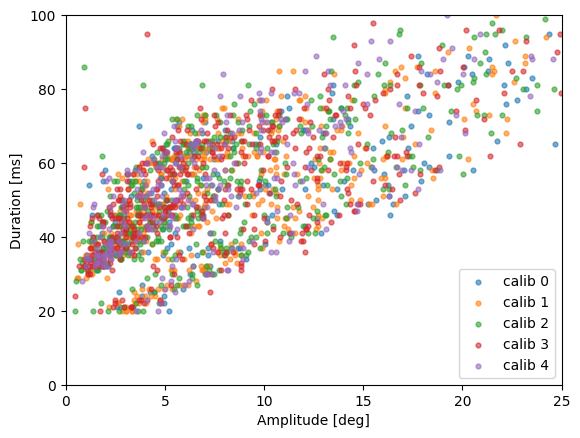

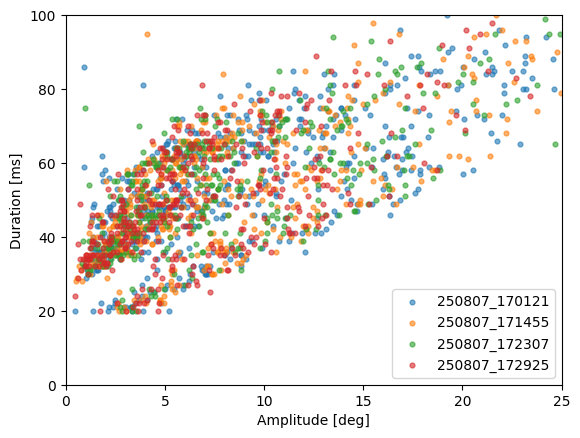

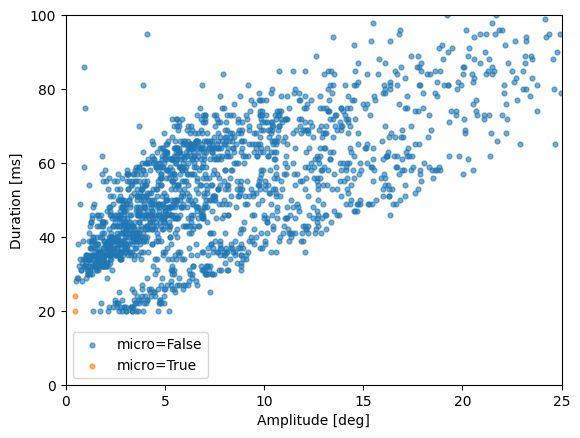

                  amplitude_deg  duration_ms  peak_velocity_deg_s
calib_session_id                                                 
0                      6.311060         53.0           407.620612
1                      6.697134         52.0           417.031999
2                      6.623364         51.0           406.572514
3                      6.136543         51.0           412.211937
4                      6.515129         53.0           417.042164
               amplitude_deg  duration_ms  peak_velocity_deg_s
block_id                                                      
250807_170121       6.690775         53.0           423.311219
250807_171455       6.626217         53.0           417.019541
250807_172307       6.750134         54.0           404.294595
250807_172925       5.939922         49.0           397.986598


In [7]:
for calib, d in df.groupby("calib_session_id"):
    plt.scatter(
        d["amplitude_deg"],
        d["duration_ms"],
        s=12,
        alpha=0.6,
        label=f"calib {calib}"
    )

plt.xlabel("Amplitude [deg]")
plt.ylabel("Duration [ms]")
plt.ylim(0, 100)
plt.xlim(0, 25)
plt.legend()
plt.show()

for block, d in df.groupby("block_id"):
    plt.scatter(
        d["amplitude_deg"],
        d["duration_ms"],
        s=12,
        alpha=0.6,
        label=str(block)
    )

plt.xlabel("Amplitude [deg]")
plt.ylabel("Duration [ms]")
plt.ylim(0, 100)
plt.xlim(0, 25)
plt.legend()
plt.show()

for is_micro, d in df.groupby("is_microsaccade"):
    plt.scatter(
        d["amplitude_deg"],
        d["duration_ms"],
        s=12,
        alpha=0.6,
        label=f"micro={is_micro}"
    )

plt.xlabel("Amplitude [deg]")
plt.ylabel("Duration [ms]")
plt.ylim(0, 100)
plt.xlim(0, 25)
plt.legend()
plt.show()

print(df.groupby("calib_session_id")[["amplitude_deg", "duration_ms", "peak_velocity_deg_s"]].median())
print(df.groupby("block_id")[["amplitude_deg", "duration_ms", "peak_velocity_deg_s"]].median())

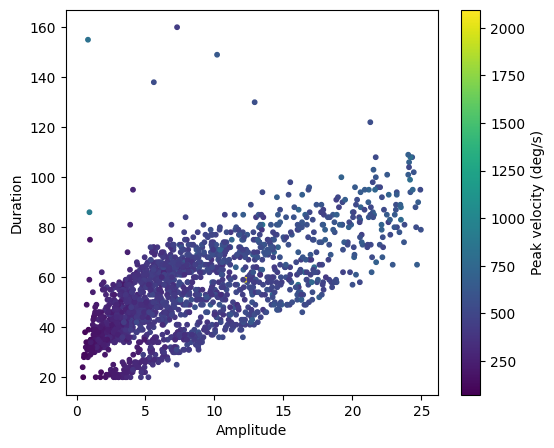

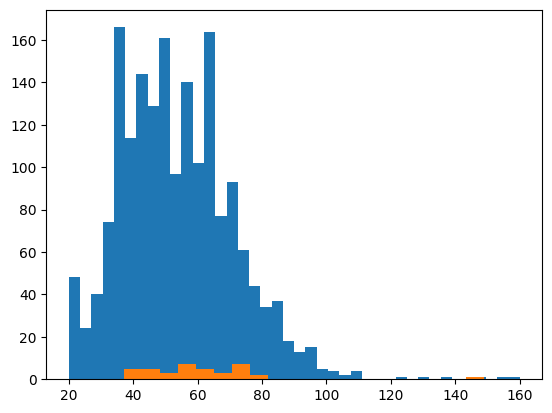

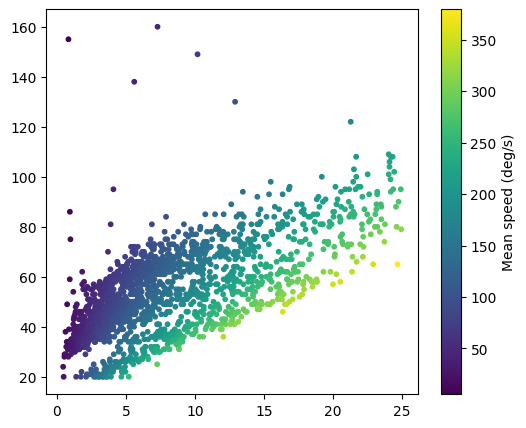

In [10]:
plt.figure(figsize=(6,5))

plt.scatter(
    df["amplitude_deg"],
    df["duration_ms"],
    c=df["peak_velocity_deg_s"],
    s=10,
    cmap="viridis",
)

plt.colorbar(label="Peak velocity (deg/s)")
plt.xlabel("Amplitude")
plt.ylabel("Duration")
plt.show()

plt.hist(df["duration_ms"], bins=40)

lower = df[
    (df["amplitude_deg"] > 8) &
    (df["amplitude_deg"] < 12) &
    (df["duration_ms"] < 50)
]

upper = df[
    (df["amplitude_deg"] > 8) &
    (df["amplitude_deg"] < 12) &
    (df["duration_ms"] > 60)
]

lower[[
    "peak_velocity_deg_s",
    "duration_ms",
    "amplitude_deg"
]].describe()

upper[[
    "peak_velocity_deg_s",
    "duration_ms",
    "amplitude_deg"
]].describe()

subset = df[
    (df["amplitude_deg"] > 9.8) &
    (df["amplitude_deg"] < 10.2)
]

plt.hist(subset["duration_ms"], bins=20)
plt.show()

df["mean_speed"] = df["amplitude_deg"] / (df["duration_ms"] / 1000)

plt.figure(figsize=(6,5))
plt.scatter(
    df["amplitude_deg"],
    df["duration_ms"],
    c=df["mean_speed"],
    cmap="viridis",
    s=10,
)
plt.colorbar(label="Mean speed (deg/s)")

print(np.sort(df["duration_ms"].unique())[:30])

plt.figure(figsize=(10,3))
plt.hist(df["duration_ms"], bins=np.arange(0,160,1))





===== LOWER BAND =====
       peak_velocity_deg_s  mean_speed
count            10.000000   10.000000
mean            441.046204  240.269440
std              63.254662   17.930744
min             368.824876  217.797272
25%             393.031185  226.555656
50%             426.412450  235.292707
75%             494.787230  254.912374
max             549.513160  267.229073

===== UPPER BAND =====
       peak_velocity_deg_s  mean_speed
count            18.000000   18.000000
mean            493.277145  140.521376
std              74.602159   21.044480
min             387.357626   68.384312
25%             419.869040  135.945063
50%             488.466219  142.032342
75%             546.654913  152.027470
max             632.917798  164.466081

===== LOWER BAND SACCADE INDEX =====
count    10.000000
mean      1.400000
std       1.173788
min       0.000000
25%       0.250000
50%       1.500000
75%       2.000000
max       3.000000
Name: saccade_index, dtype: float64

===== UPPER BAND SACCADE

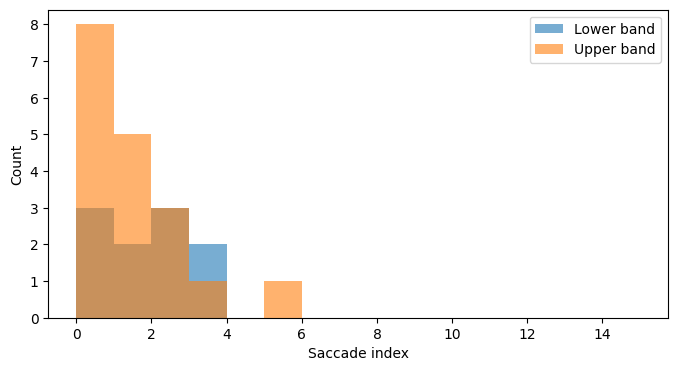

LOWER ISI
count      7.000000
mean     160.000000
std       70.334913
min       53.000000
25%      123.000000
50%      153.000000
75%      210.500000
max      247.000000
Name: inter_saccadic_interval_ms, dtype: float64

UPPER ISI
count     10.000000
mean     150.100000
std       71.503613
min       22.000000
25%      113.750000
50%      166.500000
75%      183.000000
max      264.000000
Name: inter_saccadic_interval_ms, dtype: float64


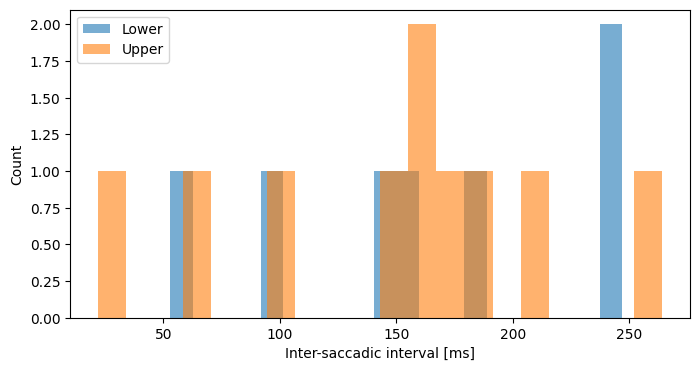


LOWER saccade index
count    10.000000
mean      1.400000
std       1.173788
min       0.000000
25%       0.250000
50%       1.500000
75%       2.000000
max       3.000000
Name: saccade_index, dtype: float64

UPPER saccade index
count    18.000000
mean      1.055556
std       1.349171
min       0.000000
25%       0.000000
50%       1.000000
75%       1.750000
max       5.000000
Name: saccade_index, dtype: float64


In [21]:
# ------------------------------------------------------------
# Compare lower vs upper band
# ------------------------------------------------------------

# Add mean speed if not already present
df["mean_speed"] = df["amplitude_deg"] / (df["duration_ms"] / 1000)

# Define the two bands
lower = df[
    (df["amplitude_deg"].between(9.8, 10.2)) &
    (df["duration_ms"] < 50)
].copy()

upper = df[
    (df["amplitude_deg"].between(9.8, 10.2)) &
    (df["duration_ms"] > 60)
].copy()

# -------------------------
# Peak velocity and mean speed
# -------------------------
print("===== LOWER BAND =====")
print(lower[["peak_velocity_deg_s", "mean_speed"]].describe())

print("\n===== UPPER BAND =====")
print(upper[["peak_velocity_deg_s", "mean_speed"]].describe())



# -------------------------
# Saccade index
# -------------------------
print("\n===== LOWER BAND SACCADE INDEX =====")
print(lower["saccade_index"].describe())

print("\n===== UPPER BAND SACCADE INDEX =====")
print(upper["saccade_index"].describe())

plt.figure(figsize=(8,4))

plt.hist(
    lower["saccade_index"],
    bins=np.arange(
        min(df["saccade_index"]),
        max(df["saccade_index"]) + 2
    ),
    alpha=0.6,
    label="Lower band"
)

plt.hist(
    upper["saccade_index"],
    bins=np.arange(
        min(df["saccade_index"]),
        max(df["saccade_index"]) + 2
    ),
    alpha=0.6,
    label="Upper band"
)

plt.xlabel("Saccade index")
plt.ylabel("Count")
plt.legend()
plt.show()



# Compute ISI if missing
if "inter_saccadic_interval_ms" not in df.columns:
    df = df.sort_values(["block_id", "trial", "saccade_index"]).copy()
    df["prev_stop_time_ms"] = df.groupby(["block_id", "trial"])["stop_time_ms"].shift(1)
    df["inter_saccadic_interval_ms"] = df["start_time_ms"] - df["prev_stop_time_ms"]

df["mean_speed"] = df["amplitude_deg"] / (df["duration_ms"] / 1000)

lower = df[
    (df["amplitude_deg"].between(9.8, 10.2)) &
    (df["duration_ms"] < 50)
].copy()

upper = df[
    (df["amplitude_deg"].between(9.8, 10.2)) &
    (df["duration_ms"] > 60)
].copy()

print("LOWER ISI")
print(lower["inter_saccadic_interval_ms"].describe())

print("\nUPPER ISI")
print(upper["inter_saccadic_interval_ms"].describe())

plt.figure(figsize=(8, 4))
plt.hist(lower["inter_saccadic_interval_ms"].dropna(), bins=20, alpha=0.6, label="Lower")
plt.hist(upper["inter_saccadic_interval_ms"].dropna(), bins=20, alpha=0.6, label="Upper")
plt.xlabel("Inter-saccadic interval [ms]")
plt.ylabel("Count")
plt.legend()
plt.show()

print("\nLOWER saccade index")
print(lower["saccade_index"].describe())

print("\nUPPER saccade index")
print(upper["saccade_index"].describe())